# Hybrid spelling and punctuation assistant

This notebook is the main experiment surface for the current project architecture.

The project uses one final system:

```text
HybridCorrector = candidate generator + top-k edit Transformer + source-aware punctuation head + RuBERT context reranker + quality guard
```

The model does not rewrite the whole sentence. It predicts local token edits from top-k candidates and source-aware punctuation labels. v6 uses rank-consistent top-k labels, safe split-candidates, whole-line/window runtime, protected punctuation gaps, RuBERT context reranking, morphology-guarded dictionary gates, candidate-aware KEEP training and clean-noise filtering. Keyboard-neighbor typos are intentionally not used.


## 1. Environment

In [1]:
import os
import sys
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Jupyter keeps imported modules in memory. After code changes we must force
# the kernel to import the current files from src/, otherwise old model classes
# can be used and cell 20 may fail while loading/evaluating the model.
PROJECT_MODULES = [
    "candidate_generator",
    "data_preparation",
    "edit_labels",
    "evaluate_hybrid",
    "hybrid_corrector",
    "hybrid_model",
    "hybrid_preprocessor",
    "morphology_guard",
    "quality_guard",
    "text_utils",
    "train_hybrid",
    "training_augmentation",
]
def reload_project_modules(names=None):
    names = PROJECT_MODULES if names is None else names
    for module_name in names:
        sys.modules.pop(module_name, None)

reload_project_modules()

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Project root:", ROOT)

for folder in ["models", "report", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)


Python: 3.10.12
TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /home/daniil/projects/ai-assistant


## 2. Experiment Configuration

Change hyperparameters here before running the rest of the notebook.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data paths
DATASET_PATH = Path("data/processed/dataset.csv")
TRAIN_PATH = Path("data/processed/train.csv")
VAL_PATH = Path("data/processed/val.csv")
TEST_PATH = Path("data/processed/test.csv")
RAW_TEXTS_PATH = Path("data/raw/texts.txt")

# Dataset regeneration from data/raw/texts.txt
REGENERATE_DATASET = True
SAMPLES_PER_TEXT = 3
TRAIN_CLEAN_RATIO = 0.45
EVAL_CLEAN_RATIO = 0.35

CURRICULUM = [
    {"name": "spelling_light", "profile": "spelling_light", "p": 0.32},
    {"name": "spelling_medium", "profile": "spelling_medium", "p": 0.16},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.26},
    {"name": "mixed", "profile": "mixed", "p": 0.15},
    {"name": "space_errors", "profile": "space_errors", "p": 0.08},
    {"name": "hard", "profile": "hard", "p": 0.03},
]

# Hybrid labels and model
MODEL_VERSION = 6
MAX_LENGTH = 128
MIN_VOCAB_FREQ = 1
MAX_VOCAB_SIZE = 80_000
CANDIDATE_MIN_FREQ = 1
CANDIDATE_MAX_DISTANCE = 1
CANDIDATE_TOP_K = 5
MIN_DICTIONARY_SCORE = 1.0
SAFE_SPLIT_CANDIDATES = True

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT_RATE = 0.30
LEARNING_RATE = 1e-4

# Candidate-aware KEEP augmentation
KEEP_CANDIDATE_AUGMENTATION = True
KEEP_CANDIDATE_PROBABILITY = 0.35
KEEP_CANDIDATE_MAX_PER_EXAMPLE = 3
KEEP_CANDIDATE_MAX_SEARCHES = 8_000
KEEP_CANDIDATE_CLEAN_ONLY = True
CLEAN_AUDIT_MAX_WORD_SEARCHES = 5_000

# Punctuation training weights
PUNCT_CHANGE_WEIGHT = 8.0
FINAL_PUNCT_WEIGHT = 8.0
CLEAN_PUNCT_KEEP_WEIGHT = 2.0
DIRTY_PUNCT_KEEP_WEIGHT = 1.0

# Training
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 2

# Context reranker
CONTEXT_RERANKER_ENABLED = True
CONTEXT_MODEL_NAME = "DeepPavlov/rubert-base-cased"

# Evaluation
EVAL_SAMPLE_SIZE = None  # set None for full test split
STRICTNESS = "strict"  # strict | normal | aggressive
PUNCTUATION_MODE = "conservative"  # conservative | none | legacy

MODEL_PATH = Path("models/hybrid_corrector.keras")
PREPROCESSOR_PATH = Path("models/hybrid_preprocessor.pkl")
CANDIDATE_GENERATOR_PATH = Path("models/candidate_generator.pkl")
CONFIG_PATH = Path("models/hybrid_config.json")
TRAINING_LOG_PATH = Path("models/hybrid_training_log.csv")


## 3. Optional Dataset Regeneration

This cell uses the current project generator. It does not add keyboard-neighbor typos.


In [3]:
from data_preparation import DatasetGenerator, split_texts

if REGENERATE_DATASET:
    if not RAW_TEXTS_PATH.exists():
        raise FileNotFoundError(f"Missing raw texts: {RAW_TEXTS_PATH}")

    generator = DatasetGenerator()
    texts = generator.load_texts_from_file(str(RAW_TEXTS_PATH))
    train_texts, val_texts, test_texts = split_texts(
        texts,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        seed=SEED,
    )

    df_train = generator.generate_dataset_curriculum(
        train_texts,
        samples_per_text=SAMPLES_PER_TEXT,
        clean_ratio=TRAIN_CLEAN_RATIO,
        curriculum=CURRICULUM,
    )
    df_train["split"] = "train"

    df_val = generator.generate_dataset_curriculum(
        val_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=CURRICULUM,
    )
    df_val["split"] = "val"

    df_test = generator.generate_dataset_curriculum(
        test_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=CURRICULUM,
    )
    df_test["split"] = "test"

    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")

    print("Regenerated dataset:", len(df))
else:
    print("Dataset regeneration skipped.")


Генерация датасета (CURRICULUM)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47997/47997 [00:03<00:00, 15863.31it/s]


Создано 143991 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5999/5999 [00:00<00:00, 41546.62it/s]


Создано 5999 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6001/6001 [00:00<00:00, 41318.14it/s]


Создано 6001 примеров (curriculum)
Regenerated dataset: 155991


## 4. Load And Inspect Dataset

Dataset rows: 155991
Train/val/test: 143991 5999 6001


,error_text,correct_text,difficulty,error_types,split
0,"Именно езму и приписывают авторство идеи, но с...","Именно ему и приписывают авторство идеи, но са...",spelling_light,spelling_extra,train
1,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",clean,clean,train
2,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",spelling_light,spelling_double,train
3,По официальной нформации Управления ветеринари...,По официальной информации Управления ветеринар...,spelling_light,spelling_delete,train
4,По официальной информации Управления ветерина...,По официальной информации Управления ветеринар...,punctuation_only,punct_extra_comma|space_duplicate,train


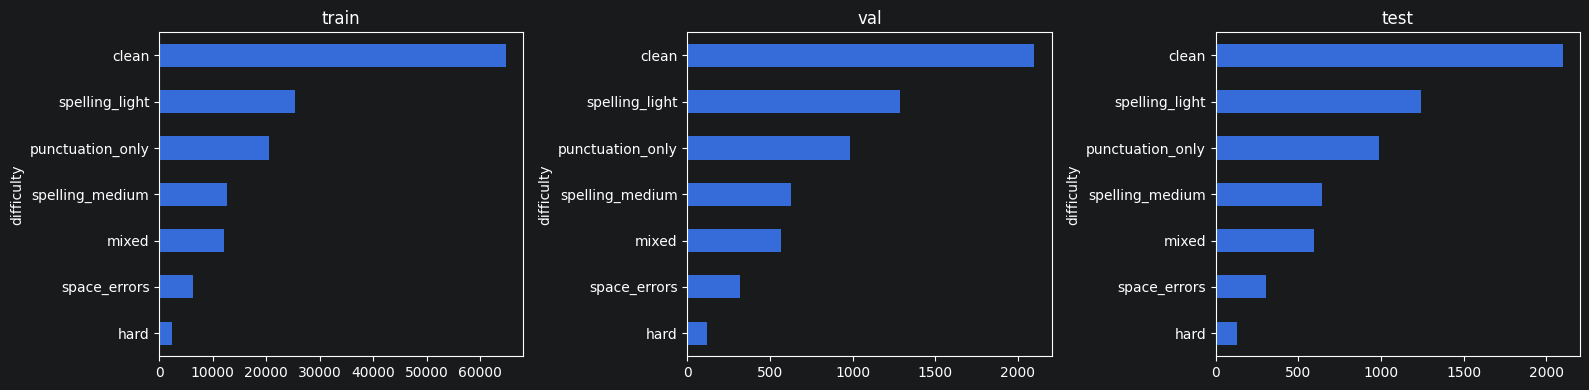

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
if "split" in df.columns:
    df_train = df[df["split"] == "train"].copy()
    df_val = df[df["split"] == "val"].copy()
    df_test = df[df["split"] == "test"].copy()
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_val = pd.read_csv(VAL_PATH)
    df_test = pd.read_csv(TEST_PATH)

print("Dataset rows:", len(df))
print("Train/val/test:", len(df_train), len(df_val), len(df_test))
display(df.head(5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, part, title in [
    (axes[0], df_train, "train"),
    (axes[1], df_val, "val"),
    (axes[2], df_test, "test"),
]:
    part["difficulty"].value_counts().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 5. Build Hybrid Training Labels

In [5]:
reload_project_modules(["candidate_generator", "edit_labels", "training_augmentation", "text_utils", "morphology_guard"])
from candidate_generator import CandidateGenerator
from edit_labels import build_examples_from_dataframe
from training_augmentation import filter_noisy_clean_rows

provisional_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=False,
)

all_rows = pd.concat([df_train, df_val, df_test], ignore_index=True)
_, clean_noise_audit, suspicious_texts = filter_noisy_clean_rows(
    all_rows,
    provisional_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_noise_filter_path = Path("report/clean_noise_filter.csv")
clean_noise_audit.to_csv(clean_noise_filter_path, index=False, encoding="utf-8")
print("Clean noise filter rows:", len(clean_noise_audit), "->", clean_noise_filter_path)

if suspicious_texts:
    df_train = df_train.loc[~df_train["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_val = df_val.loc[~df_val["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_test = df_test.loc[~df_test["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Filtered dataset rows:", len(df), "removed texts:", len(suspicious_texts))

train_examples, train_label_stats = build_examples_from_dataframe(df_train, max_tokens=MAX_LENGTH)
val_examples, val_label_stats = build_examples_from_dataframe(df_val, max_tokens=MAX_LENGTH)

print("Train label stats:", train_label_stats)
print("Val label stats:", val_label_stats)

if not train_examples or not val_examples:
    raise RuntimeError("Not enough aligned hybrid examples. Check dataset quality and MAX_LENGTH.")

if not hasattr(train_examples[0], "source_punct_labels"):
    raise RuntimeError("Stale edit_labels module detected. Rerun cell 2, then rerun cells 10-12.")

action_counter = Counter(label for ex in train_examples for label in ex.action_labels)
punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.target_punct_labels)
source_punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.source_punct_labels)

print("Action labels:", action_counter)
print("Source punctuation labels:", source_punct_counter)
print("Target punctuation labels:", punct_counter)
if len(clean_noise_audit):
    display(clean_noise_audit.head(10))


/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Clean noise filter rows: 413 -> report/clean_noise_filter.csv
Filtered dataset rows: 154934 removed texts: 413
Train label stats: {'rows': 143025, 'kept': 142221, 'skipped': 804, 'clean': 64351}
Val label stats: {'rows': 5964, 'kept': 5926, 'skipped': 38, 'clean': 2086}
Action labels: Counter({'KEEP': 1903935, 'REPLACE_0': 77186, 'DELETE': 78})
Source punctuation labels: Counter({'NONE': 1710194, ',': 152960, '.': 112031, ':': 3454, '?': 1908, ';': 357, '!': 295})
Target punctuation labels: Counter({'NONE': 1703383, ',': 146052, '.': 125503, ':': 3541, '?': 2070, '!': 337, ';': 313})


,word,candidate,candidate_score,candidate_distance,text
0,действующих,действующий,2.110874,1,Еще по предварительным итогам голосования стал...
1,посколько,поскольку,3.921578,1,"Дашкова: Я сейчас буду раздваиваться, поскольк..."
2,месье,месте,4.675823,1,Изображенное тут же вмонтированное в стену кат...
3,следующей,следующий,3.262690,1,Референт начальника предприятия Геннадий Сорок...
4,основных,основные,2.406719,1,В 2001 году фильм был удостоен шести японских ...
5,большим,большие,2.691348,1,Бюджет Петербурга теперь будет не просто больш...
6,уставным,уставный,1.091042,1,ООО «ИСК» с уставным капиталом в 10 тысяч рубл...
7,потерпевшей,потерпевший,1.688879,1,А через несколько минут грабитель был задержан...
8,знаменитости,знаменитость,2.718499,1,"За последний год знаменитости, пожелавшие сбро..."
9,больших,большие,2.691348,1,Цена больших букетов в цветочных магазинах сос...


## 6. Candidate Generator And Vectorization

In [6]:
reload_project_modules(["candidate_generator", "hybrid_preprocessor", "training_augmentation", "morphology_guard", "text_utils"])
from candidate_generator import CandidateGenerator
from hybrid_preprocessor import HybridPreprocessor
from training_augmentation import augment_keep_candidates, build_clean_candidate_audit, populate_top_k_candidates

candidate_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=SAFE_SPLIT_CANDIDATES,
    safe_split_only=True,
)
candidate_generator.save(CANDIDATE_GENERATOR_PATH)
print("Candidate generator saved:", CANDIDATE_GENERATOR_PATH)
print("Known vocabulary size:", len(candidate_generator.frequencies))

clean_audit = build_clean_candidate_audit(
    pd.concat([df_train, df_val, df_test], ignore_index=True),
    candidate_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_audit_path = Path("report/clean_candidate_audit.csv")
clean_audit.to_csv(clean_audit_path, index=False, encoding="utf-8")
print("Clean candidate audit rows:", len(clean_audit), "->", clean_audit_path)
if len(clean_audit):
    display(clean_audit.head(10))

train_examples, train_topk_candidate_stats = populate_top_k_candidates(
    train_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
val_examples, val_topk_candidate_stats = populate_top_k_candidates(
    val_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
print("Top-k train candidate stats:", train_topk_candidate_stats)
print("Top-k val candidate stats:", val_topk_candidate_stats)
print("Train target rank distribution:", train_topk_candidate_stats.get("target_rank_distribution", {}))
print("Train candidate coverage:", train_topk_candidate_stats.get("candidate_coverage_rate"))

train_examples, train_keep_candidate_stats = augment_keep_candidates(
    train_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=KEEP_CANDIDATE_MAX_SEARCHES,
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
val_examples, val_keep_candidate_stats = augment_keep_candidates(
    val_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=max(1, KEEP_CANDIDATE_MAX_SEARCHES // 4),
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED + 1,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
print("Candidate-aware train KEEP stats:", train_keep_candidate_stats)
print("Candidate-aware val KEEP stats:", val_keep_candidate_stats)

preprocessor = HybridPreprocessor(
    max_length=MAX_LENGTH,
    min_freq=MIN_VOCAB_FREQ,
    max_vocab_size=MAX_VOCAB_SIZE,
    candidate_top_k=CANDIDATE_TOP_K,
)
preprocessor.fit(train_examples)
preprocessor.save(PREPROCESSOR_PATH)

x_train, y_train, sw_train = preprocessor.vectorize_examples(
    train_examples,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)
x_val, y_val, sw_val = preprocessor.vectorize_examples(
    val_examples,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)

if "source_punct_ids" not in x_train or x_train["candidate_ids"].ndim != 3:
    raise RuntimeError("Stale HybridPreprocessor detected. Rerun cell 2, then rerun cells 10-12.")

print("Hybrid vocab size:", preprocessor.vocab_size)
print("Candidate top-k:", preprocessor.candidate_top_k)
print("x_train token_ids:", x_train["token_ids"].shape)
print("x_train candidate_ids:", x_train["candidate_ids"].shape)
print("x_train source_punct_ids:", x_train["source_punct_ids"].shape)
print("y_train action:", y_train["action"].shape)
print("sample weights:", sw_train["action"].shape)


Candidate generator saved: models/candidate_generator.pkl
Known vocabulary size: 83785
Clean candidate audit rows: 229 -> report/clean_candidate_audit.csv


,split,word,candidate,candidate_score,candidate_distance,source_known,text
0,train,этого,того,5.929846,1,True,"До этого Гуцул допустила, что может баллотиров..."
1,train,чтобы,чтоб,1.688879,1,True,"Затем молодые родители расчленили тело, разлож..."
2,train,вынести,внести,2.290459,1,True,"Затем молодые родители расчленили тело, разлож..."
3,train,также,такие,4.423247,1,True,В 2007 году планируется выделить 73 миллиона р...
4,train,больше,большое,3.017280,1,True,Компания объявила в официальном аккаунте на We...
5,train,никогда,некогда,1.610918,1,True,«Локомотив» никогда не выигрывал трофей.
6,train,вполне,волне,1.433987,1,True,"Даже сам маэстро утверждает, что его последние..."
7,train,больше,большое,3.017280,1,True,"Кажется, даже наоборот: чем сложнее и необычне..."
8,train,этого,того,5.929846,1,True,"По уверению законодателей, с этого момента он ..."
9,train,никогда,некогда,1.610918,1,True,"Надеемся никогда не услышать ее вновь!"" ""Сочин..."


Top-k train candidate stats: {'examples': 142221, 'tokens': 1981199, 'oracle_replace_tokens': 77186, 'target_candidate_hits': 67156, 'oracle_injected_tokens': 10030, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 309165, 'cache_hits': 1836998, 'candidate_searches': 144201, 'target_rank_distribution': {'0': 72034, '1': 4188, '3': 155, '2': 687, '4': 122}, 'candidate_coverage_rate': 0.8700541548985568}
Top-k val candidate stats: {'examples': 5926, 'tokens': 82448, 'oracle_replace_tokens': 3803, 'target_candidate_hits': 3028, 'oracle_injected_tokens': 775, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 15778, 'cache_hits': 54737, 'candidate_searches': 27711, 'target_rank_distribution': {'0': 3492, '1': 249, '3': 13, '2': 42, '4': 7}, 'candidate_coverage_rate': 0.796213515645543}
Train target rank distribution: {'0': 72034, '1': 4188, '3': 155, '2': 687, '4': 122}
Train candidate coverage: 0.8700541548985568
Candidate-aware train KEEP stats: {'examples': 142221, 'chan

## 7. Build Model

In [7]:
reload_project_modules(["hybrid_model"])
from hybrid_model import build_hybrid_model

model = build_hybrid_model(
    vocab_size=preprocessor.vocab_size,
    max_length=MAX_LENGTH,
    action_classes=preprocessor.action_classes,
    punct_classes=preprocessor.punct_classes,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    candidate_top_k=CANDIDATE_TOP_K,
)
input_names = {inp.name.split(":")[0].split("/")[-1] for inp in model.inputs}
if "source_punct_ids" not in input_names or "candidate_ids" not in input_names:
    raise RuntimeError("Model was built without V6 inputs. Rerun cell 2, then rerun cells 10-14.")
model.summary()


Model: "HybridEditPunctuationTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ candidate_ids       │ (None, 128, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_punct_ids    │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_candidate_em… │ (None, 128, 128)  │ 20,580,352 │ token_ids[0][0],  │
│ (TokenCandidateEmb… │                   │            │ candidate_ids[0]… │
│                     │                   │            │ source_punct_ids… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 128, 128)  │    132,480 │ token_candidate_… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_2     │ (None, 128, 128)  │    132,480 │ encoder_block_1[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 128, 128)  │          0 │ encoder_block_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action (Dense)      │ (None, 128, 7)    │        903 │ shared_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punct (Dense)       │ (None, 128, 8)    │      1,032 │ shared_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,847,247 (79.53 MB)

 Trainable params: 20,847,247 (79.53 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

This cell tracks train/validation loss and writes a CSV log to `models/hybrid_training_log.csv`.


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger, TerminateOnNaN

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODEL_PATH), monitor="val_loss", save_best_only=True, verbose=1),
    CSVLogger(str(TRAINING_LOG_PATH)),
    TerminateOnNaN(),
]

history = model.fit(
    x_train,
    y_train,
    sample_weight=sw_train,
    validation_data=(x_val, y_val, sw_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_PATH)
config = {
    "model_version": MODEL_VERSION,
    "requires_source_punct_ids": True,
    "requires_top_k_candidates": True,
    "requires_context_reranker": CONTEXT_RERANKER_ENABLED,
    "model_path": str(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH),
    "candidate_generator_path": str(CANDIDATE_GENERATOR_PATH),
    "max_length": MAX_LENGTH,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "vocab_size": preprocessor.vocab_size,
    "candidate_min_freq": CANDIDATE_MIN_FREQ,
    "candidate_max_distance": CANDIDATE_MAX_DISTANCE,
    "candidate_top_k": CANDIDATE_TOP_K,
    "safe_split_candidates": SAFE_SPLIT_CANDIDATES,
    "min_dictionary_score": MIN_DICTIONARY_SCORE,
    "keep_candidate_augmentation": KEEP_CANDIDATE_AUGMENTATION,
    "keep_candidate_probability": KEEP_CANDIDATE_PROBABILITY,
    "keep_candidate_max_per_example": KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    "keep_candidate_max_searches": KEEP_CANDIDATE_MAX_SEARCHES,
    "keep_candidate_clean_only": KEEP_CANDIDATE_CLEAN_ONLY,
    "clean_audit_max_word_searches": CLEAN_AUDIT_MAX_WORD_SEARCHES,
    "punct_change_weight": PUNCT_CHANGE_WEIGHT,
    "final_punct_weight": FINAL_PUNCT_WEIGHT,
    "clean_punct_keep_weight": CLEAN_PUNCT_KEEP_WEIGHT,
    "dirty_punct_keep_weight": DIRTY_PUNCT_KEEP_WEIGHT,
    "context_reranker_enabled": CONTEXT_RERANKER_ENABLED,
    "context_model_name": CONTEXT_MODEL_NAME,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "ff_dim": FF_DIM,
    "num_layers": NUM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_label_stats": train_label_stats,
    "val_label_stats": val_label_stats,
    "train_topk_candidate_stats": train_topk_candidate_stats,
    "val_topk_candidate_stats": val_topk_candidate_stats,
    "train_keep_candidate_stats": train_keep_candidate_stats,
    "val_keep_candidate_stats": val_keep_candidate_stats,
    "clean_candidate_audit_path": str(clean_audit_path),
    "clean_noise_filter_path": str(clean_noise_filter_path),
    "clean_noise_filter_rows": int(len(clean_noise_audit)),
    "clean_noise_filter_texts": int(len(suspicious_texts)),
    "best_val_loss": float(min(history.history["val_loss"])),
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved model:", MODEL_PATH)
print("Saved config:", CONFIG_PATH)


Epoch 1/30


W0000 00:00:1777527830.736350  534236 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1777527830.766659  534236 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


2220/2223 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - action_acc: 0.8157 - action_loss: 0.0138 - loss: 0.0401 - punct_acc: 0.3754 - punct_loss: 0.0752

W0000 00:00:1777527878.078814  534234 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1777527878.103264  534234 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


2223/2223 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - action_acc: 0.8156 - action_loss: 0.0138 - loss: 0.0401 - punct_acc: 0.3755 - punct_loss: 0.0751

W0000 00:00:1777527897.131940  534238 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1777527897.141303  534238 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1777527899.876490  534231 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1777527899.881746  534231 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_loss improved from None to 0.05412, saving model to models/hybrid_corrector.keras
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 79s 22ms/step - action_acc: 0.7072 - action_loss: 0.0070 - loss: 0.0235 - punct_acc: 0.4012 - punct_loss: 0.0474 - val_action_acc: 0.8476 - val_action_loss: 0.0435 - val_loss: 0.0541 - val_punct_acc: 0.4881 - val_punct_loss: 0.0304 - learning_rate: 1.0000e-04
Epoch 2/30
2222/2223 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - action_acc: 0.4504 - action_loss: 0.0032 - loss: 0.0125 - punct_acc: 0.4715 - punct_loss: 0.0264
Epoch 2: val_loss improved from 0.05412 to 0.04742, saving model to models/hybrid_corrector.keras
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - action_acc: 0.4196 - action_loss: 0.0029 - loss: 0.0111 - punct_acc: 0.4629 - punct_loss: 0.0234 - val_action_acc: 0.3383 - val_action_loss: 0.0392 - val_loss: 0.0474 - val_punct_acc: 0.5324 - val_punct_loss: 0.0236 - learning_rate: 1.0000e-04
Epoch 3/30
2219/2223 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - action_acc: 0

## 9. Training Curves

,action_acc,action_loss,loss,punct_acc,punct_loss,val_action_acc,val_action_loss,val_loss,val_punct_acc,val_punct_loss,learning_rate
3,0.375975,0.001818,0.006291,0.587587,0.012777,0.131614,0.039366,0.048341,0.740577,0.025684,0.000100
4,0.379902,0.001583,0.005244,0.662843,0.010456,0.263588,0.039869,0.050945,0.746251,0.031688,0.000100
5,0.413257,0.001397,0.004174,0.694540,0.007932,0.235394,0.043514,0.054017,0.752937,0.030077,0.000050
6,0.403134,0.001318,0.003712,0.699361,0.006839,0.217782,0.041508,0.052920,0.779907,0.032660,0.000050
7,0.415527,0.001225,0.003248,0.709744,0.005778,0.242803,0.042828,0.055087,0.770270,0.035081,0.000025


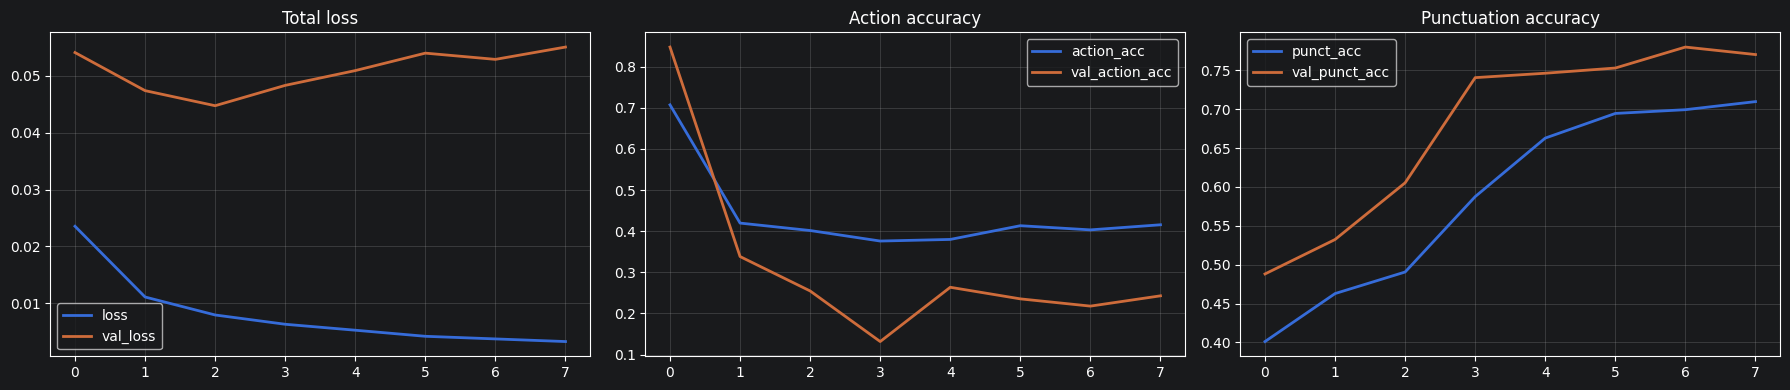

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Total loss")
axes[0].grid(True, alpha=0.3)

for col in ["action_acc", "val_action_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[1], linewidth=2, label=col)
axes[1].set_title("Action accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for col in ["punct_acc", "val_punct_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[2], linewidth=2, label=col)
axes[2].set_title("Punctuation accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluate

In [10]:
# Reload project modules before evaluation. This prevents stale Jupyter imports
# from trying to load a model with an old class definition.
reload_project_modules()

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing model config: {CONFIG_PATH}. Run training cell 16 first.")

model_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
if model_config.get("model_version", 0) < 6:
    raise RuntimeError(
        "The saved model is obsolete for the V6 runtime. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )
if not model_config.get("requires_source_punct_ids", False) or not model_config.get("requires_top_k_candidates", False):
    raise RuntimeError(
        "The saved model is from an old input format. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )

from evaluate_hybrid import evaluate_hybrid

summary = evaluate_hybrid(
    dataset_path=str(TEST_PATH),
    sample_size=EVAL_SAMPLE_SIZE,
    output_dir="report",
    strictness=STRICTNESS,
    punctuation_mode=PUNCTUATION_MODE,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    candidate_top_k=CANDIDATE_TOP_K,
    context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
    context_model_name=CONTEXT_MODEL_NAME,
)
summary


/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'token_candidate_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/sr

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Evaluated 50/5945 examples
Evaluated 100/5945 examples
Evaluated 150/5945 examples
Evaluated 200/5945 examples
Evaluated 250/5945 examples
Evaluated 300/5945 examples
Evaluated 350/5945 examples
Evaluated 400/5945 examples
Evaluated 450/5945 examples
Evaluated 500/5945 examples
Evaluated 550/5945 examples
Evaluated 600/5945 examples
Evaluated 650/5945 examples
Evaluated 700/5945 examples
Evaluated 750/5945 examples
Evaluated 800/5945 examples
Evaluated 850/5945 examples
Evaluated 900/5945 examples
Evaluated 950/5945 examples
Evaluated 1000/5945 examples
Evaluated 1050/5945 examples
Evaluated 1100/5945 examples
Evaluated 1150/5945 examples
Evaluated 1200/5945 examples
Evaluated 1250/5945 examples
Evaluated 1300/5945 examples
Evaluated 1350/5945 examples
Evaluated 1400/5945 examples
Evaluated 1450/5945 examples
Evaluated 1500/5945 examples
Evaluated 1550/5945 examples
Evaluated 1600/5945 examples
Evaluated 1650/5945 examples
Evaluated 1700/5945 examples
Evaluated 1750/5945 examples
Evalu

{'examples': 5945,
 'exact_match': 0.5042893187552565,
 'mean_input_cer': 0.014000550464980551,
 'mean_pred_cer': 0.009360448693847214,
 'mean_cer_delta': 0.004640101771133336,
 'improved_rate': 0.30815811606391924,
 'worse_rate': 0.004205214465937763,
 'unchanged_rate': 0.6851135407905803,
 'unchanged_wrong_rate': 0.5184993531694696,
 'clean_overcorrection_rate': 0.005288461538461539,
 'word_overcorrection_rate': 0.004326923076923077,
 'punct_overcorrection_rate': 0.0009615384615384616,
 'punct_input_similarity': 0.8928492935214638,
 'punct_pred_similarity': 0.9368843239815413,
 'punct_similarity_delta': 0.04403503046007751,
 'mean_punct_count_error': 0.2622371740958789,
 'mean_confidence': 0.9952535335028713,
 'accepted_rate': 0.9899074852817493,
 'spacing_only_overcorrection_rate': 0.0038461538461538464,
 'layout_changed_without_edits_count': 0,
 'clean_slice': {'examples': 2080,
  'exact_match': 0.9947115384615385,
  'mean_input_cer': 0.0,
  'mean_pred_cer': 5.7322175650974544e-05,

## 11. Analyze Reports

In [11]:
summary_path = Path("report/summary.json")
analysis_path = Path("report/error_analysis.csv")
by_type_path = Path("report/error_metrics_by_type.csv")
worst_path = Path("report/worst_cases.csv")
punct_diag_path = Path("report/punct_edit_diagnostics.csv")

if summary_path.exists():
    print(summary_path.read_text(encoding="utf-8"))

analysis_df = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
by_type_df = pd.read_csv(by_type_path) if by_type_path.exists() else pd.DataFrame()
worst_df = pd.read_csv(worst_path) if worst_path.exists() else pd.DataFrame()
punct_diag_df = pd.read_csv(punct_diag_path) if punct_diag_path.exists() else pd.DataFrame()

print("Analysis rows:", len(analysis_df))
if not analysis_df.empty:
    clean_df = analysis_df[analysis_df["input_cer"] == 0]
    dirty_df = analysis_df[analysis_df["input_cer"] > 0]
    quality_rows = []
    for name, part in [("clean", clean_df), ("dirty", dirty_df), ("all", analysis_df)]:
        if part.empty:
            continue
        quality_rows.append({
            "slice": name,
            "examples": len(part),
            "mean_input_cer": part["input_cer"].mean(),
            "mean_pred_cer": part["pred_cer"].mean(),
            "mean_cer_delta": part["cer_delta"].mean(),
            "worse_rate": part["worse"].mean(),
            "clean_overcorrection_rate": part["clean_overcorrection"].mean() if name == "clean" else np.nan,
            "word_overcorrection_rate": part["word_overcorrection"].mean() if name == "clean" and "word_overcorrection" in part else np.nan,
            "punct_overcorrection_rate": part["punct_overcorrection"].mean() if name == "clean" and "punct_overcorrection" in part else np.nan,
            "spacing_only_overcorrection_rate": part["spacing_only_overcorrection"].mean() if name == "clean" and "spacing_only_overcorrection" in part else np.nan,
            "layout_changed_without_edits": part["layout_changed_without_edits"].sum() if "layout_changed_without_edits" in part else np.nan,
            "punct_similarity_delta": part["punct_pred_similarity"].mean() - part["punct_input_similarity"].mean(),
            "accepted_rate": part["accepted"].mean(),
        })
    display(pd.DataFrame(quality_rows))

if not by_type_df.empty:
    display(by_type_df.head(20))
if not worst_df.empty:
    columns = [
        "error_types", "input_cer", "pred_cer", "cer_delta", "guard_reason",
        "word_edit_count", "punct_edit_count", "error_text", "predicted_text", "correct_text",
    ]
    display(worst_df[[c for c in columns if c in worst_df.columns]].head(20))

if not punct_diag_df.empty:
    print("Punctuation diagnostics rows:", len(punct_diag_df))
    display(punct_diag_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    for column in ["protected_gap", "punct_position_type", "window_conflict_resolved"]:
        if column in punct_diag_df:
            display(punct_diag_df[column].value_counts(dropna=False).head(10).to_frame("count"))
    display(punct_diag_df.head(20))

print("Full test command after training:")
print(
    "PYTHONPATH=src .venv/bin/python src/evaluate.py "
    "--dataset data/processed/test.csv --all --output-dir report/full_v6 "
    "--strictness strict --punctuation-mode conservative --candidate-top-k 5"
)


{
  "examples": 5945,
  "exact_match": 0.5042893187552565,
  "mean_input_cer": 0.014000550464980551,
  "mean_pred_cer": 0.009360448693847214,
  "mean_cer_delta": 0.004640101771133336,
  "improved_rate": 0.30815811606391924,
  "worse_rate": 0.004205214465937763,
  "unchanged_rate": 0.6851135407905803,
  "unchanged_wrong_rate": 0.5184993531694696,
  "clean_overcorrection_rate": 0.005288461538461539,
  "word_overcorrection_rate": 0.004326923076923077,
  "punct_overcorrection_rate": 0.0009615384615384616,
  "punct_input_similarity": 0.8928492935214638,
  "punct_pred_similarity": 0.9368843239815413,
  "punct_similarity_delta": 0.04403503046007751,
  "mean_punct_count_error": 0.2622371740958789,
  "mean_confidence": 0.9952535335028713,
  "accepted_rate": 0.9899074852817493,
  "spacing_only_overcorrection_rate": 0.0038461538461538464,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 2080,
    "exact_match": 0.9947115384615385,
    "mean_input_cer": 0.0,
    "mean_

,slice,examples,mean_input_cer,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,spacing_only_overcorrection_rate,layout_changed_without_edits,punct_similarity_delta,accepted_rate
0,clean,2080,0.000000,0.000057,-0.000057,0.005288,0.005288,0.004327,0.000962,0.003846,0,-0.000165,1.000000
1,dirty,3865,0.021535,0.014367,0.007168,0.003622,NaN,NaN,NaN,NaN,0,0.067822,0.984476
2,all,5945,0.014001,0.009360,0.004640,0.004205,NaN,NaN,NaN,NaN,0,0.044035,0.989907


,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,...,punct_overcorrection_rate,punct_input_similarity,punct_pred_similarity,punct_similarity_delta,mean_punct_count_error,mean_confidence,accepted_rate,spacing_only_overcorrection_rate,layout_changed_without_edits_count,error_type
0,2080,0.994712,0.000000,0.000057,-0.000057,0.000000,0.005288,0.994712,NaN,0.005288,...,0.000962,1.000000,0.999835,-0.000165,0.000962,0.996042,1.000000,0.003846,0,clean
1,6,0.000000,0.020986,0.020986,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,...,NaN,0.675000,0.675000,0.000000,2.000000,0.995657,1.000000,NaN,0,punct_wrong_colon_to_semicolon
2,7,0.000000,0.020658,0.017553,0.003106,0.142857,0.000000,0.857143,0.857143,NaN,...,NaN,0.509524,0.509524,0.000000,2.000000,0.996310,1.000000,NaN,0,punct_wrong_question_to_period
3,90,0.033333,0.020714,0.016690,0.004025,0.311111,0.000000,0.688889,0.688889,NaN,...,NaN,0.789088,0.826033,0.036946,0.944444,0.994475,1.000000,NaN,0,punct_remove_comma_before_clause
4,356,0.039326,0.033264,0.026451,0.006813,0.404494,0.000000,0.595506,0.595506,NaN,...,NaN,0.785411,0.864802,0.079391,0.665730,0.995100,0.963483,NaN,0,space_add_before_punct
5,242,0.012397,0.029979,0.023116,0.006864,0.404959,0.000000,0.590909,0.590909,NaN,...,NaN,0.794348,0.857653,0.063305,0.752066,0.994560,0.966942,NaN,0,space_remove_after_punct
6,131,0.000000,0.029402,0.022367,0.007035,0.473282,0.000000,0.526718,0.526718,NaN,...,NaN,0.818507,0.829174,0.010667,1.038168,0.993580,0.984733,NaN,0,punct_remove_comma
7,642,0.024922,0.032310,0.025004,0.007306,0.395639,0.003115,0.599688,0.599688,NaN,...,NaN,0.765373,0.791641,0.026268,1.043614,0.994895,0.990654,NaN,0,punct_extra_comma
8,626,0.140575,0.027971,0.020633,0.007338,0.471246,0.006390,0.511182,0.511182,NaN,...,NaN,0.851182,0.902600,0.051418,0.372204,0.994461,0.985623,NaN,0,spelling_delete
9,112,0.035714,0.031508,0.024008,0.007500,0.446429,0.000000,0.553571,0.553571,NaN,...,NaN,0.686909,0.711994,0.025085,0.982143,0.994789,1.000000,NaN,0,punct_remove_all_commas


,error_types,input_cer,pred_cer,cer_delta,guard_reason,word_edit_count,punct_edit_count,error_text,predicted_text,correct_text
0,clean,0.000000,0.022222,-0.022222,accepted,1,0,Треть из трехсотлетней истории нашего города.,Треть из трехсот летней истории нашего города.,Треть из трехсотлетней истории нашего города.
1,spelling_delete,0.019608,0.039216,-0.019608,accepted,1,0,Готические сооры называли Библией для неграмот...,Готические споры называли Библией для неграмот...,Готические соборы называли Библией для неграмо...
2,clean,0.000000,0.019608,-0.019608,accepted,0,1,"«Противник строит укрепления, блокпосты, барри...","«Противник строит укрепления блокпосты, баррик...","«Противник строит укрепления, блокпосты, барри..."
3,clean,0.000000,0.018519,-0.018519,accepted,1,0,"Это что, сверхвоспитание?» — задался вопросом ...","Это что, сверх воспитание?» — задался вопросом...","Это что, сверхвоспитание?» — задался вопросом ..."
4,spelling_double|punct_extra_comma|space_duplicate,0.041096,0.054795,-0.013699,accepted,1,0,"Из постпетровских, властителей циркачей любила...","Из пост петровских, властителей циркачей любил...",Из постпетровских властителей циркачей любила ...
5,spelling_replace,0.013333,0.026667,-0.013333,accepted,1,0,"По его мнению, новая падача может оттолкнуть о...","По его мнению, новая задача может оттолкнуть о...","По его мнению, новая подача может оттолкнуть о..."
6,spelling_delete,0.012658,0.025316,-0.012658,accepted,1,0,"Кроме ого, «Бавария» не проигрывала дебютантам...","Кроме ово, «Бавария» не проигрывала дебютантам...","Кроме того, «Бавария» не проигрывала дебютанта..."
7,spelling_delete,0.012048,0.024096,-0.012048,accepted,1,0,"""Жидкая броня"" представляет собой гель из твер...","""Жидкая броня"" представляет собой гель из твер...","""Жидкая броня"" представляет собой гель из твер..."
8,spelling_replace,0.010870,0.021739,-0.010870,accepted,1,0,"А в остальном все также томко, выразительно и ...","А в остальном все также том ко, выразительно и...","А в остальном все также тонко, выразительно и ..."
9,spelling_replace,0.010753,0.021505,-0.010753,accepted,1,0,Начальник учебной части Виктор Уренцев боспеши...,Начальник учебной части Виктор Уренцев бо спеш...,Начальник учебной части Виктор Уренцев поспеши...


Punctuation diagnostics rows: 82593


...

,count
protected_gap,
False,78922
True,3671


,count
punct_position_type,
internal,73601
final,5321
protected,3671


,count
window_conflict_resolved,
False,82593


,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,index,word,source_punct,...,applied,blocked_reason,is_final,protected_gap,punct_position_type,window_id,window_conflict_resolved,text,predicted,target_text
0,0,spelling_light,spelling_replace,False,False,False,True,0,Перевод,NaN,...,False,same_as_source,False,True,protected,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
1,0,spelling_light,spelling_replace,False,False,False,True,1,4,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
2,0,spelling_light,spelling_replace,False,False,False,True,2,декабря,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
3,0,spelling_light,spelling_replace,False,False,False,True,3,Святополк,",",...,False,low_confidence_or_margin,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
4,0,spelling_light,spelling_replace,False,False,False,True,4,Владимир,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
5,0,spelling_light,spelling_replace,False,False,False,True,5,и,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
6,0,spelling_light,spelling_replace,False,False,False,True,6,Олег,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
7,0,spelling_light,spelling_replace,False,False,False,True,7,заключили,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
8,0,spelling_light,spelling_replace,False,False,False,True,8,мир,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
9,0,spelling_light,spelling_replace,False,False,False,True,9,на,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег...","Перевод: ""4 декабря Святополк, Владимир и Олег..."


Full test command after training:
PYTHONPATH=src .venv/bin/python src/evaluate.py --dataset data/processed/test.csv --all --output-dir report/full_v6 --strictness strict --punctuation-mode conservative --candidate-top-k 5


## 12. Manual Runtime Checks

In [12]:
from hybrid_corrector import HybridCorrector

corrector = HybridCorrector(strictness=STRICTNESS, punctuation_mode=PUNCTUATION_MODE, min_dictionary_score=MIN_DICTIONARY_SCORE, context_reranker_enabled=CONTEXT_RERANKER_ENABLED, context_model_name=CONTEXT_MODEL_NAME)
print("Model trained:", corrector.is_trained)

if len(df_test) > 0:
    sample_rows = df_test.sample(min(5, len(df_test)), random_state=SEED)
    for i, row in sample_rows.iterrows():
        result = corrector.correct(str(row["error_text"]), return_details=True)
        print("=" * 80)
        print("ERROR:  ", row["error_text"])
        print("PRED:   ", result.corrected)
        print("TARGET: ", row["correct_text"])
        print("confidence:", round(result.confidence, 3), "accepted:", result.accepted, "reason:", result.guard_reason)
        print("edits:", result.edits[:8])


/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'token_candidate_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/daniil/projects/ai-assistant/.venv/lib/python3.10/site-packages/keras/sr

Model trained: True


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ERROR:   Имеенноего влиянию шители Петербурга и Ленинградской области обязаны сегодняшним ночным морозам,
PRED:    Имеенноего влиянию жители Петербурга и Ленинградской области обязаны сегодняшним ночным морозам.
TARGET:  Именно его влиянию жители Петербурга и Ленинградской области обязаны сегодняшним ночным морозам.
confidence: 0.992 accepted: True reason: accepted
edits: [CorrectionEdit(index=2, source='шители', target='жители', action='REPLACE_0', confidence=0.9993240237236023, candidate_source='dictionary', candidate_distance=1, candidate_score=3.855071922202427, candidate_rank=0, context_score=-inf, context_margin=nan, reranked=False, reranker_reason='context_low_margin'), CorrectionEdit(index=10, source=',', target='.', action='PUNCT', confidence=0.9667497277259827, candidate_source='', candidate_distance=0, candidate_score=0.0, candidate_rank=-1, context_score=0.0, context_margin=0.0, reranked=False, reranker_reason='')]
ERROR:   Какие официальные выводы деелает господин Могилевс

## 13. Strictness Comparison (Optional)

This can be slow because it runs inference several times. Reduce `sample_size` if needed.


In [ ]:
RUN_STRICTNESS_COMPARISON = False
COMPARISON_SAMPLE_SIZE = 100

if RUN_STRICTNESS_COMPARISON:
    rows = []
    for mode in ["strict", "normal", "aggressive"]:
        result = evaluate_hybrid(
            dataset_path=str(TEST_PATH),
            sample_size=COMPARISON_SAMPLE_SIZE,
            output_dir=f"report/strictness_{mode}",
            strictness=mode,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
        )
        result["strictness"] = mode
        rows.append(result)
    comparison_df = pd.DataFrame(rows)
    display(comparison_df[["strictness", "mean_pred_cer", "mean_cer_delta", "worse_rate", "clean_overcorrection_rate", "accepted_rate"]])
else:
    print("Strictness comparison skipped.")


## 14. GUI

After training, the desktop app uses the same `HybridCorrector` artifacts from `models/`.

```bash
PYTHONPATH=src .venv/bin/python app/main.py
```
